# 03 — Evaluation & Results

Loads trained models, runs them on the test period (Dec 2025), and computes:
- Cumulative return
- Sharpe ratio
- Maximum drawdown
- Turnover (number of trades)

Compared against:
- **Buy-and-hold** (single ticker)
- **Equal-weight buy-and-hold** (all 3 tickers)
- **Momentum baseline** (buy if last 5-day return > 0, else hold)

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from trading_env import TradingEnv, make_envs
from stable_baselines3 import PPO, DQN

DATA_DIR    = PROJECT_ROOT / 'data'
MODELS_DIR  = PROJECT_ROOT / 'models'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

TICKERS      = ['NVDA', 'GOOG', 'TSLA']
TRAIN_CUTOFF = '2025-10-31'
INITIAL_CASH = 10_000.0

daily         = pd.read_csv(DATA_DIR / 'daily_features.csv',         parse_dates=['date'])
daily_finbert = pd.read_csv(DATA_DIR / 'daily_features_finbert.csv', parse_dates=['date'])
print('VADER dataset:  ', daily.shape)
print('FinBERT dataset:', daily_finbert.shape)


VADER dataset:   (384, 33)
FinBERT dataset: (384, 33)


## 1. Metrics Helper Functions

In [2]:
def sharpe_ratio(returns, risk_free=0.0, periods_per_year=252):
    """Annualized Sharpe ratio from a series of period returns."""
    excess = returns - risk_free / periods_per_year
    if excess.std() < 1e-8:
        return 0.0
    return float(excess.mean() / excess.std() * np.sqrt(periods_per_year))

def max_drawdown(portfolio_values):
    """Maximum peak-to-trough drawdown."""
    vals = np.array(portfolio_values)
    peak = np.maximum.accumulate(vals)
    drawdown = (vals - peak) / peak
    return float(drawdown.min())

def cumulative_return(portfolio_values):
    return float((portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0])

def compute_metrics(history_df):
    pv = history_df['portfolio_value'].values
    daily_returns = np.diff(pv) / pv[:-1]
    trades = (history_df['action'] != 1).sum()  # non-hold actions
    return {
        'cumulative_return': cumulative_return(pv),
        'sharpe_ratio':      sharpe_ratio(pd.Series(daily_returns)),
        'max_drawdown':      max_drawdown(pv),
        'turnover':          int(trades),
        'final_value':       float(pv[-1]),
    }

print('Metrics helpers ready.')

Metrics helpers ready.


## 2. Evaluate RL Agents

In [3]:
def run_agent(model, env):
    obs, _ = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)
    return env.get_history()

ALGO_CLASSES = {'PPO': PPO, 'DQN': DQN}
STATE_TYPES  = ['price', 'sentiment_vader', 'sentiment_finbert']
ENV_KWARGS = dict(
    reward_mode='log_return',
    drawdown_penalty=0.0,
    volatility_penalty=0.0,
    use_volatility_gate=True,
    vol_threshold_quantile=0.3,
)

# Maps state_type -> (model suffix, env key, dataset)
STATE_CONFIG = {
    'price':             ('price',            'test_price',            daily),
    'sentiment_vader':   ('sentiment_vader',  'test_sentiment_basic',  daily),
    'sentiment_finbert': ('sentiment_finbert','test_sentiment_basic',  daily_finbert),
}

all_results = []
histories   = {}

for ticker in TICKERS:
    envs_vader   = make_envs(daily,         ticker, TRAIN_CUTOFF, env_kwargs=ENV_KWARGS)
    envs_finbert = make_envs(daily_finbert, ticker, TRAIN_CUTOFF, env_kwargs=ENV_KWARGS)

    for algo_name in ['PPO', 'DQN']:
        for state_type in STATE_TYPES:
            model_suffix, env_key, _ = STATE_CONFIG[state_type]
            model_path = MODELS_DIR / f'{ticker}_{algo_name}_{model_suffix}.zip'
            if not model_path.exists():
                print(f'  MISSING: {model_path.name} — run notebook 02 first')
                continue

            model = ALGO_CLASSES[algo_name].load(str(model_path))
            envs  = envs_finbert if state_type == 'sentiment_finbert' else envs_vader
            history = run_agent(model, envs[env_key])
            metrics = compute_metrics(history)

            key = (ticker, algo_name, state_type)
            histories[key] = history
            all_results.append({'ticker': ticker, 'algo': algo_name, 'state': state_type, **metrics})

results_df = pd.DataFrame(all_results)
print('RL evaluation done.')
results_df


RL evaluation done.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,PPO,price,-0.009765,-0.293285,-0.077634,24,9902.347009
1,NVDA,PPO,sentiment_vader,0.032172,1.475849,-0.046468,37,10321.715592
2,NVDA,PPO,sentiment_finbert,0.051055,2.410264,-0.026201,24,10510.547790
3,NVDA,DQN,price,0.071697,3.899740,-0.014896,34,10716.968129
4,NVDA,DQN,sentiment_vader,0.013145,1.395297,-0.010626,34,10131.447523
5,NVDA,DQN,sentiment_finbert,0.011267,1.420368,-0.010645,34,10112.674273
6,GOOG,PPO,price,0.084755,4.993660,-0.013610,27,10847.546887
7,GOOG,PPO,sentiment_vader,0.071434,3.110535,-0.034392,37,10598.782047
8,GOOG,PPO,sentiment_finbert,0.060846,2.668072,-0.043765,35,10494.046920
9,GOOG,DQN,price,0.076931,3.602294,-0.024533,28,10769.305928


In [4]:
print('=== Sentiment Uplift vs Price-only ===')
delta_rows = []
for ticker in TICKERS:
    sub = results_df[results_df['ticker'] == ticker]
    for algo in ['PPO', 'DQN']:
        price_row = sub[(sub['algo'] == algo) & (sub['state'] == 'price')]
        if len(price_row) == 0:
            continue
        price_row = price_row.iloc[0]
        for state in ['sentiment_vader', 'sentiment_finbert']:
            sent_row = sub[(sub['algo'] == algo) & (sub['state'] == state)]
            if len(sent_row) == 0:
                continue
            sent_row = sent_row.iloc[0]
            delta_rows.append({
                'ticker': ticker,
                'algo': algo,
                'sentiment': state,
                'return_uplift_pp': round((sent_row['cumulative_return'] - price_row['cumulative_return']) * 100, 2),
                'sharpe_uplift':    round(sent_row['sharpe_ratio'] - price_row['sharpe_ratio'], 3),
            })

delta_df = pd.DataFrame(delta_rows)
print(delta_df.to_string(index=False))


=== Sentiment Uplift vs Price-only ===
ticker algo         sentiment  return_uplift_pp  sharpe_uplift
  NVDA  PPO   sentiment_vader              4.19          1.769
  NVDA  PPO sentiment_finbert              6.08          2.704
  NVDA  DQN   sentiment_vader             -5.86         -2.504
  NVDA  DQN sentiment_finbert             -6.04         -2.479
  GOOG  PPO   sentiment_vader             -1.33         -1.883
  GOOG  PPO sentiment_finbert             -2.39         -2.326
  GOOG  DQN   sentiment_vader             -6.39         -2.482
  GOOG  DQN sentiment_finbert             -4.24         -0.035
  TSLA  PPO   sentiment_vader              0.03         -0.389
  TSLA  PPO sentiment_finbert             -1.27         -0.789
  TSLA  DQN   sentiment_vader             -4.08         -2.056
  TSLA  DQN sentiment_finbert             -6.17         -2.876


## 3. Compute Baselines

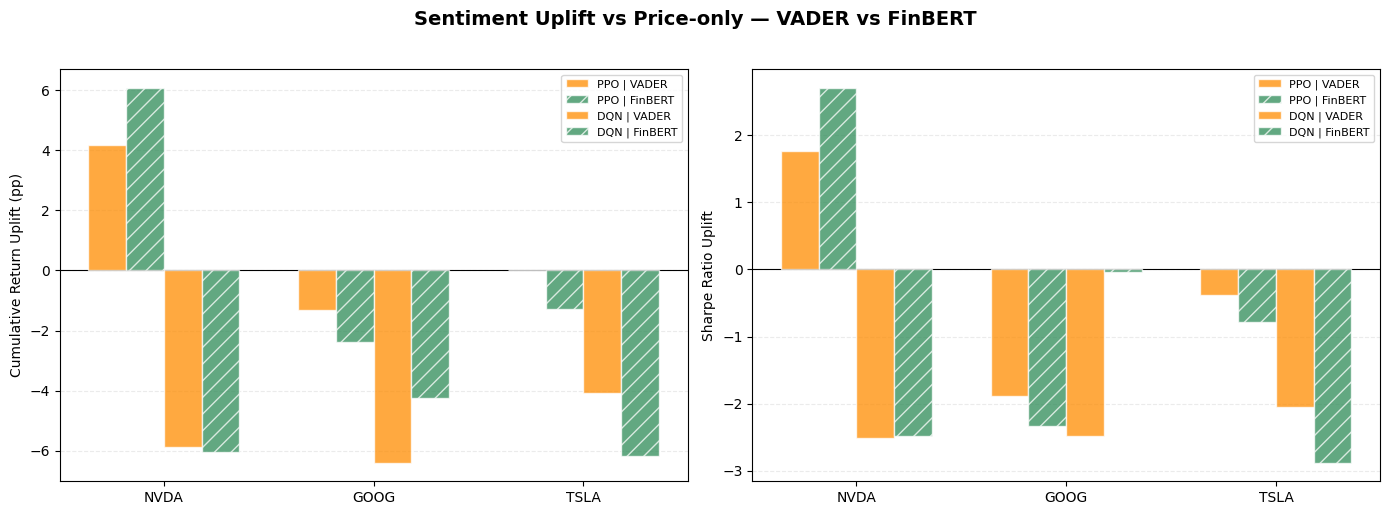

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig.suptitle('Sentiment Uplift vs Price-only — VADER vs FinBERT',
             fontsize=14, fontweight='bold', y=1.02)

metrics = [
    ('return_uplift_pp', 'Cumulative Return Uplift (pp)'),
    ('sharpe_uplift',    'Sharpe Ratio Uplift'),
]
scorer_colors  = {'sentiment_vader': 'darkorange', 'sentiment_finbert': 'seagreen'}
scorer_labels  = {'sentiment_vader': 'VADER', 'sentiment_finbert': 'FinBERT'}
bar_width = 0.18
x = np.arange(len(TICKERS))

for ax, (metric, ylabel) in zip(axes, metrics):
    ax.set_facecolor('white')
    ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)

    offsets = {'PPO': {'sentiment_vader': -1.5, 'sentiment_finbert': -0.5},
               'DQN': {'sentiment_vader':  0.5, 'sentiment_finbert':  1.5}}

    for algo, algo_color in [('PPO', 'royalblue'), ('DQN', 'darkorange')]:
        for scorer in ['sentiment_vader', 'sentiment_finbert']:
            vals = []
            for ticker in TICKERS:
                row = delta_df[(delta_df['ticker'] == ticker) &
                               (delta_df['algo'] == algo) &
                               (delta_df['sentiment'] == scorer)]
                vals.append(row[metric].values[0] if len(row) else 0)
            offset = offsets[algo][scorer] * bar_width
            label = f'{algo} | {scorer_labels[scorer]}'
            hatch = '//' if scorer == 'sentiment_finbert' else ''
            ax.bar(x + offset, vals, bar_width, label=label,
                   color=scorer_colors[scorer], alpha=0.75, hatch=hatch,
                   edgecolor='white', zorder=3)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(TICKERS)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sentiment_uplift_vader_vs_finbert.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
baseline_results = []
baseline_histories = {}

def buy_and_hold(test_df, initial_cash=INITIAL_CASH):
    """Buy as many shares as possible on day 0, hold until end."""
    prices = test_df['close'].values
    shares = int(initial_cash // prices[0])
    cash = initial_cash - shares * prices[0]
    portfolio = cash + shares * prices
    daily_ret = np.diff(portfolio) / portfolio[:-1]
    actions = np.ones(len(prices), dtype=int)  # all hold
    actions[0] = 2  # buy
    return pd.DataFrame({
        'portfolio_value': portfolio,
        'action': actions,
    }), portfolio

def momentum_baseline(test_df, initial_cash=INITIAL_CASH, window=5):
    """Buy when 5-day return is positive, sell otherwise."""
    prices = test_df['close'].values
    cash = initial_cash
    position = 0
    portfolio = []
    actions = []
    for i in range(len(prices)):
        pv = cash + position * prices[i]
        portfolio.append(pv)
        if i >= window:
            momentum = prices[i] / prices[i - window] - 1
            if momentum > 0 and position == 0 and cash >= prices[i]:
                position += 1
                cash -= prices[i]
                actions.append(2)
            elif momentum <= 0 and position > 0:
                cash += position * prices[i]
                position = 0
                actions.append(0)
            else:
                actions.append(1)
        else:
            actions.append(1)
    return pd.DataFrame({'portfolio_value': portfolio, 'action': actions}), np.array(portfolio)

for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].copy()
    if len(test_df) == 0:
        continue

    for baseline_name, fn in [('buy_and_hold', buy_and_hold), ('momentum', momentum_baseline)]:
        hist, pv = fn(test_df)
        metrics = compute_metrics(hist)
        baseline_histories[(ticker, baseline_name)] = hist
        baseline_results.append({
            'ticker': ticker, 'algo': baseline_name, 'state': 'baseline', **metrics
        })

# Equal-weight buy-and-hold across all 3 tickers
eq_cash = INITIAL_CASH / 3
eq_portfolios = []
for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].copy()
    _, pv = buy_and_hold(test_df, initial_cash=eq_cash)
    # Align lengths
    eq_portfolios.append(pv)

min_len = min(len(p) for p in eq_portfolios)
eq_total = sum(p[:min_len] for p in eq_portfolios)
eq_actions = np.ones(min_len, dtype=int)
eq_actions[0] = 2
eq_hist = pd.DataFrame({'portfolio_value': eq_total, 'action': eq_actions})
eq_metrics = compute_metrics(eq_hist)
baseline_results.append({'ticker': 'ALL', 'algo': 'equal_weight_bh', 'state': 'baseline', **eq_metrics})

baselines_df = pd.DataFrame(baseline_results)
print('Baselines computed.')
baselines_df

Baselines computed.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,buy_and_hold,baseline,-0.097824,-1.596076,-0.172512,1,9021.759766
1,NVDA,momentum,baseline,0.000482,1.206228,-0.000462,8,10004.820007
2,GOOG,buy_and_hold,baseline,0.103880,2.158179,-0.078651,1,11038.799744
3,GOOG,momentum,baseline,0.000234,0.214826,-0.001927,10,10002.340027
4,TSLA,buy_and_hold,baseline,-0.039165,-0.354468,-0.162288,1,9608.350128
5,TSLA,momentum,baseline,0.004550,2.448124,-0.002249,6,10045.500031
6,ALL,equal_weight_bh,baseline,-0.013015,-0.129131,-0.086892,1,9869.849884


## 4. Results Table

In [7]:
combined = pd.concat([results_df, baselines_df], ignore_index=True)

fmt = combined.copy()
fmt['cumulative_return'] = (fmt['cumulative_return'] * 100).round(2).astype(str) + '%'
fmt['sharpe_ratio']      = fmt['sharpe_ratio'].round(3)
fmt['max_drawdown']      = (fmt['max_drawdown'] * 100).round(2).astype(str) + '%'
fmt['final_value']       = '$' + fmt['final_value'].round(2).astype(str)

display_cols = ['ticker', 'algo', 'state', 'cumulative_return', 'sharpe_ratio', 'max_drawdown', 'turnover', 'final_value']
print('\n=== FULL RESULTS TABLE ===')
print(fmt[display_cols].to_string(index=False))

combined.to_csv(RESULTS_DIR / 'results.csv', index=False)
print('\nSaved to results/results.csv')


=== FULL RESULTS TABLE ===
ticker            algo             state cumulative_return  sharpe_ratio max_drawdown  turnover final_value
  NVDA             PPO             price            -0.98%        -0.293       -7.76%        24    $9902.35
  NVDA             PPO   sentiment_vader             3.22%         1.476       -4.65%        37   $10321.72
  NVDA             PPO sentiment_finbert             5.11%         2.410       -2.62%        24   $10510.55
  NVDA             DQN             price             7.17%         3.900       -1.49%        34   $10716.97
  NVDA             DQN   sentiment_vader             1.31%         1.395       -1.06%        34   $10131.45
  NVDA             DQN sentiment_finbert             1.13%         1.420       -1.06%        34   $10112.67
  GOOG             PPO             price             8.48%         4.994       -1.36%        27   $10847.55
  GOOG             PPO   sentiment_vader             7.14%         3.111       -3.44%        37   $10598.78


## 5. Price vs Sentiment Comparison

In [8]:
print('=== Feature Ablation: Price vs VADER vs FinBERT ===')
print()
for ticker in TICKERS:
    print(f'--- {ticker} ---')
    sub = results_df[results_df['ticker'] == ticker]
    for algo in ['PPO', 'DQN']:
        price_row = sub[(sub['algo'] == algo) & (sub['state'] == 'price')]
        vader_row = sub[(sub['algo'] == algo) & (sub['state'] == 'sentiment_vader')]
        finbert_row = sub[(sub['algo'] == algo) & (sub['state'] == 'sentiment_finbert')]
        if any(len(r) == 0 for r in [price_row, vader_row, finbert_row]):
            continue
        price_row, vader_row, finbert_row = price_row.iloc[0], vader_row.iloc[0], finbert_row.iloc[0]
        print(f'  {algo}:')
        print(f'    Price-only :  ret={price_row["cumulative_return"]*100:+.2f}%  sharpe={price_row["sharpe_ratio"]:.3f}')
        print(f'    VADER      :  ret={vader_row["cumulative_return"]*100:+.2f}%  sharpe={vader_row["sharpe_ratio"]:.3f}  Δret={((vader_row["cumulative_return"]-price_row["cumulative_return"])*100):+.2f}pp')
        print(f'    FinBERT    :  ret={finbert_row["cumulative_return"]*100:+.2f}%  sharpe={finbert_row["sharpe_ratio"]:.3f}  Δret={((finbert_row["cumulative_return"]-price_row["cumulative_return"])*100):+.2f}pp')
    print()


=== Feature Ablation: Price vs VADER vs FinBERT ===

--- NVDA ---
  PPO:
    Price-only :  ret=-0.98%  sharpe=-0.293
    VADER      :  ret=+3.22%  sharpe=1.476  Δret=+4.19pp
    FinBERT    :  ret=+5.11%  sharpe=2.410  Δret=+6.08pp
  DQN:
    Price-only :  ret=+7.17%  sharpe=3.900
    VADER      :  ret=+1.31%  sharpe=1.395  Δret=-5.86pp
    FinBERT    :  ret=+1.13%  sharpe=1.420  Δret=-6.04pp

--- GOOG ---
  PPO:
    Price-only :  ret=+8.48%  sharpe=4.994
    VADER      :  ret=+7.14%  sharpe=3.111  Δret=-1.33pp
    FinBERT    :  ret=+6.08%  sharpe=2.668  Δret=-2.39pp
  DQN:
    Price-only :  ret=+7.69%  sharpe=3.602
    VADER      :  ret=+1.31%  sharpe=1.121  Δret=-6.39pp
    FinBERT    :  ret=+3.45%  sharpe=3.567  Δret=-4.24pp

--- TSLA ---
  PPO:
    Price-only :  ret=+4.47%  sharpe=1.884
    VADER      :  ret=+4.50%  sharpe=1.495  Δret=+0.03pp
    FinBERT    :  ret=+3.20%  sharpe=1.095  Δret=-1.27pp
  DQN:
    Price-only :  ret=+6.16%  sharpe=2.950
    VADER      :  ret=+2.08%  sharp

## 6. Portfolio Value Over Time

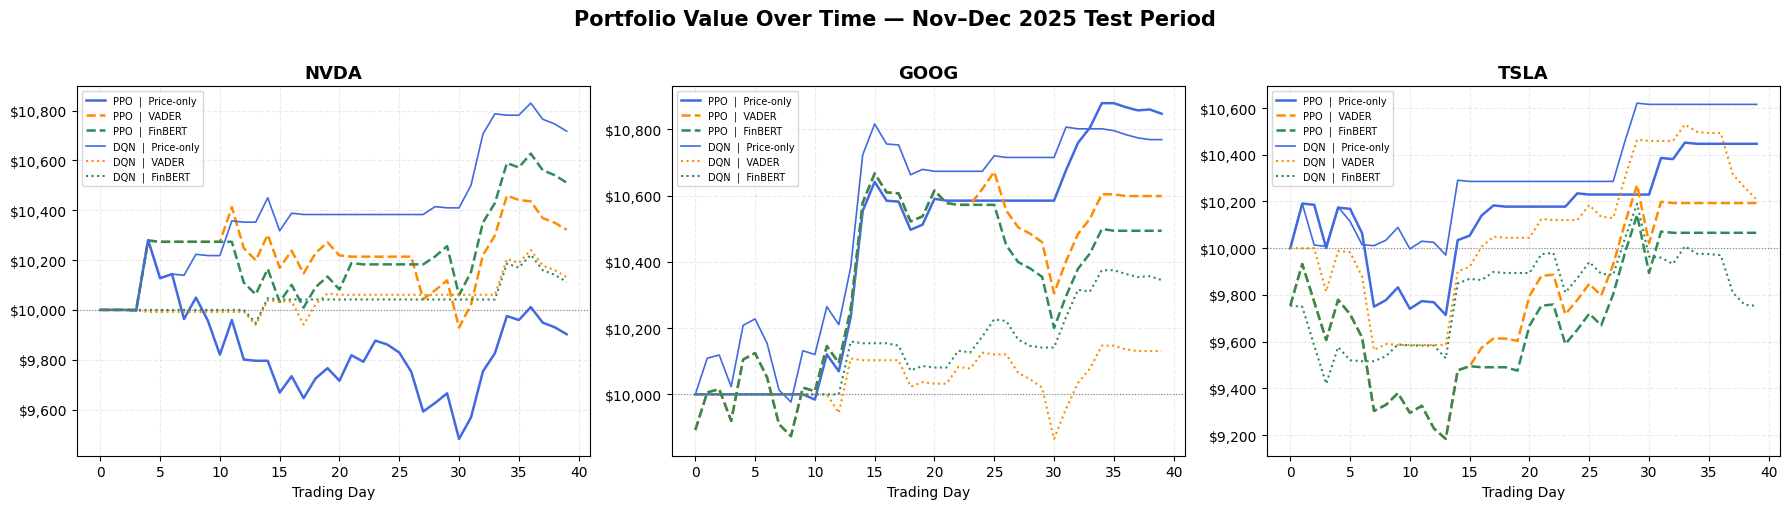

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False, facecolor='white')
fig.suptitle('Portfolio Value Over Time — Nov–Dec 2025 Test Period', fontsize=15, fontweight='bold', y=1.01)

styles = {
    ('PPO', 'price'):             ('royalblue',  '-',   1.8, 'PPO  |  Price-only'),
    ('PPO', 'sentiment_vader'):   ('darkorange', '--',  1.8, 'PPO  |  VADER'),
    ('PPO', 'sentiment_finbert'): ('seagreen',   '--',  1.8, 'PPO  |  FinBERT'),
    ('DQN', 'price'):             ('royalblue',  '-',   1.2, 'DQN  |  Price-only'),
    ('DQN', 'sentiment_vader'):   ('darkorange', ':',   1.5, 'DQN  |  VADER'),
    ('DQN', 'sentiment_finbert'): ('seagreen',   ':',   1.5, 'DQN  |  FinBERT'),
}

for ax, ticker in zip(axes, TICKERS):
    ax.set_facecolor('white')
    ax.grid(alpha=0.25, linestyle='--', zorder=0)

    for (algo, state), (color, ls, lw, label) in styles.items():
        key = (ticker, algo, state)
        if key not in histories:
            continue
        h = histories[key]
        ax.plot(h['portfolio_value'].values, color=color, linestyle=ls, linewidth=lw, label=label, zorder=3)

    ax.axhline(INITIAL_CASH, color='gray', linewidth=0.8, linestyle=':', zorder=2)
    ax.set_title(ticker, fontsize=13, fontweight='bold')
    ax.set_xlabel('Trading Day')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'portfolio_value_3way.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Sharpe Ratio Comparison

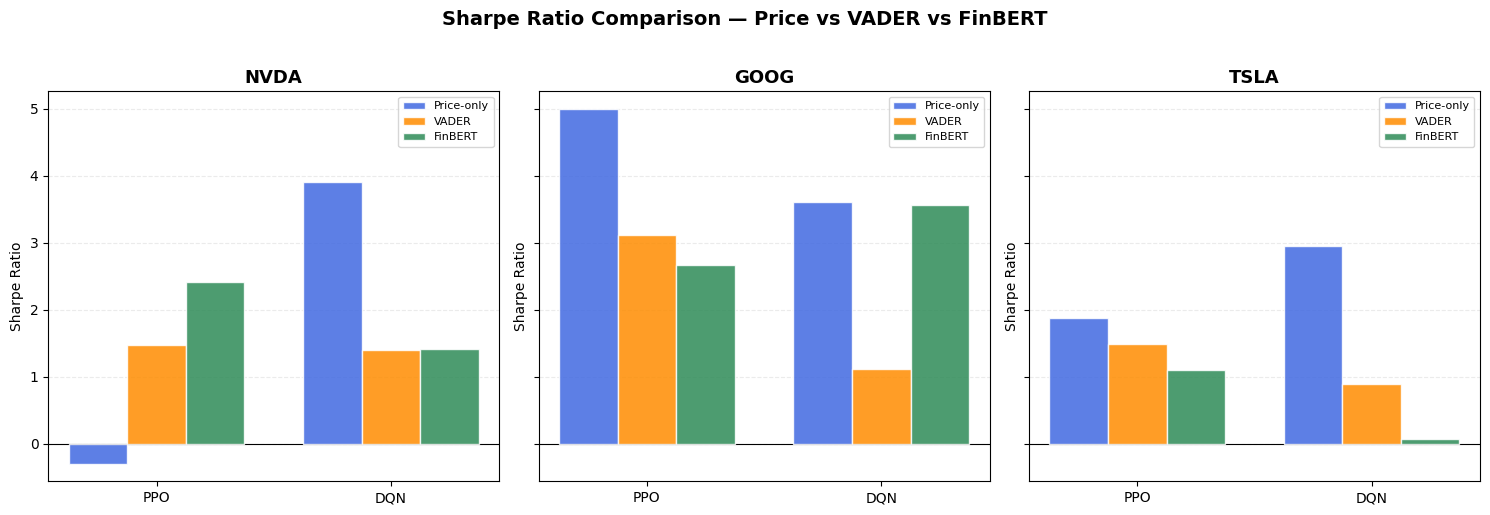

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, facecolor='white')
fig.suptitle('Sharpe Ratio Comparison — Price vs VADER vs FinBERT', fontsize=14, fontweight='bold', y=1.02)

state_palette = {'price': 'royalblue', 'sentiment_vader': 'darkorange', 'sentiment_finbert': 'seagreen'}
state_labels  = {'price': 'Price-only', 'sentiment_vader': 'VADER', 'sentiment_finbert': 'FinBERT'}
bar_width = 0.25
x = np.arange(2)  # PPO, DQN

for ax, ticker in zip(axes, TICKERS):
    ax.set_facecolor('white')
    ax.grid(axis='y', alpha=0.25, linestyle='--', zorder=0)

    for i, state in enumerate(STATE_TYPES):
        sub = results_df[(results_df['ticker'] == ticker) & (results_df['state'] == state)]
        vals = [sub[sub['algo'] == a]['sharpe_ratio'].values[0] if len(sub[sub['algo'] == a]) else 0
                for a in ['PPO', 'DQN']]
        ax.bar(x + (i - 1) * bar_width, vals, bar_width,
               label=state_labels[state], color=state_palette[state], alpha=0.85,
               edgecolor='white', zorder=3)

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(['PPO', 'DQN'])
    ax.set_title(ticker, fontsize=13, fontweight='bold')
    ax.set_ylabel('Sharpe Ratio')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sharpe_comparison_3way.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
for ticker in TICKERS:
    test_df = daily[(daily['ticker'] == ticker) & (daily['date'] > TRAIN_CUTOFF)].reset_index(drop=True)
    if len(test_df) == 0:
        continue
    threshold = test_df['article_count'].quantile(0.75)
    high_news_days = (test_df['article_count'] >= threshold)
    print(f'{ticker}: {high_news_days.sum()} high-news days (>= {threshold:.0f} articles), '
          f'{(~high_news_days).sum()} low-news days')

    for algo in ['PPO', 'DQN']:
        reward_means = {}
        for state in STATE_TYPES:
            key = (ticker, algo, state)
            if key not in histories:
                continue
            h = histories[key]
            if len(h) == 0:
                continue
            h_slice = h.iloc[:len(test_df)].copy()
            h_slice['high_news'] = high_news_days.values[:len(h_slice)]
            reward_means[state] = {
                'high': h_slice[h_slice['high_news']]['reward'].mean(),
                'low':  h_slice[~h_slice['high_news']]['reward'].mean(),
            }
        if reward_means:
            print(f'  {algo}:')
            for state, rm in reward_means.items():
                lbl = {'price': 'Price-only', 'sentiment_vader': 'VADER', 'sentiment_finbert': 'FinBERT'}[state]
                print(f'    {lbl:<12}: high-news={rm["high"]:+.5f}  low-news={rm["low"]:+.5f}')
    print()


NVDA: 11 high-news days (>= 24 articles), 30 low-news days
  PPO:
    Price-only  : high-news=-0.00001  low-news=-0.00037
    VADER       : high-news=-0.00059  low-news=+0.00114
    FinBERT     : high-news=+0.00005  low-news=+0.00156
  DQN:
    Price-only  : high-news=-0.00145  low-news=+0.00257
    VADER       : high-news=+0.00039  low-news=+0.00019
    FinBERT     : high-news=+0.00056  low-news=+0.00014

GOOG: 11 high-news days (>= 30 articles), 30 low-news days
  PPO:
    Price-only  : high-news=+0.00039  low-news=+0.00253
    VADER       : high-news=+0.00060  low-news=+0.00167
    FinBERT     : high-news=+0.00051  low-news=+0.00137
  DQN:
    Price-only  : high-news=-0.00085  low-news=+0.00262
    VADER       : high-news=+0.00018  low-news=+0.00021
    FinBERT     : high-news=-0.00057  low-news=+0.00111

TSLA: 11 high-news days (>= 32 articles), 30 low-news days
  PPO:
    Price-only  : high-news=+0.00525  low-news=-0.00052
    VADER       : high-news=+0.00457  low-news=-0.00092
  

## 8. Short-Selling Extension — Results

Evaluates the 18 short-enabled models (PPO/DQN × price/vader/finbert × 3 tickers).
Action 3 = Short: agent shorted instead of going to cash on bearish signals.


In [12]:
STATE_TYPES_SHORT = ['price_short', 'sentiment_vader_short', 'sentiment_finbert_short']

SHORT_CONFIG = {
    'price_short':             ('price_short',            'test_price_short',            daily),
    'sentiment_vader_short':   ('sentiment_vader_short',  'test_sentiment_basic_short',  daily),
    'sentiment_finbert_short': ('sentiment_finbert_short','test_sentiment_basic_short',  daily_finbert),
}

short_results = []
short_histories = {}

for ticker in TICKERS:
    envs_vader   = make_envs(daily,         ticker, TRAIN_CUTOFF, env_kwargs=ENV_KWARGS, allow_short=True)
    envs_finbert = make_envs(daily_finbert, ticker, TRAIN_CUTOFF, env_kwargs=ENV_KWARGS, allow_short=True)

    for algo_name in ['PPO', 'DQN']:
        for state_type in STATE_TYPES_SHORT:
            model_suffix, env_key, _ = SHORT_CONFIG[state_type]
            model_path = MODELS_DIR / f'{ticker}_{algo_name}_{model_suffix}.zip'
            if not model_path.exists():
                print(f'  MISSING: {model_path.name} — run short training in notebook 02 first')
                continue

            model = ALGO_CLASSES[algo_name].load(str(model_path))
            envs  = envs_finbert if 'finbert' in state_type else envs_vader
            history = run_agent(model, envs[env_key])
            metrics = compute_metrics(history)

            key = (ticker, algo_name, state_type)
            short_histories[key] = history
            short_results.append({'ticker': ticker, 'algo': algo_name, 'state': state_type, **metrics})

short_results_df = pd.DataFrame(short_results)
print('Short-enabled evaluation done.')
short_results_df


Short-enabled evaluation done.


,ticker,algo,state,cumulative_return,sharpe_ratio,max_drawdown,turnover,final_value
0,NVDA,PPO,price_short,1.084372e-01,4.011042,-0.039362,33,11296.742929
1,NVDA,PPO,sentiment_vader_short,8.502729e-02,3.116275,-0.050922,21,11058.158662
2,NVDA,PPO,sentiment_finbert_short,5.361365e-02,2.016269,-0.049458,33,10738.003526
3,NVDA,DQN,price_short,1.016436e-01,4.143624,-0.046673,28,11016.436364
4,NVDA,DQN,sentiment_vader_short,5.515346e-02,2.058285,-0.041225,38,10753.696705
5,NVDA,DQN,sentiment_finbert_short,1.540155e-01,5.715867,-0.026665,35,11761.258307
6,GOOG,PPO,price_short,1.122043e-01,4.734259,-0.024783,40,11002.091663
7,GOOG,PPO,sentiment_vader_short,6.843226e-02,3.068946,-0.035250,39,10569.092210
8,GOOG,PPO,sentiment_finbert_short,1.143397e-01,5.370435,-0.024533,35,11143.396889
9,GOOG,DQN,price_short,-5.872955e-02,-2.496199,-0.083321,29,9311.188462


In [13]:
print('=== Short-Enabled Uplift vs Long-Only Equivalents ===\n')
print(f'{"Ticker":<6} {"Algo":<5} {"Comparison":<50} {"Return Δ":>9} {"Sharpe Δ":>9}')
print('-' * 83)

pairs = [
    ('price',            'price_short'),
    ('sentiment_vader',  'sentiment_vader_short'),
    ('sentiment_finbert','sentiment_finbert_short'),
]
for ticker in TICKERS:
    for algo in ['PPO', 'DQN']:
        for long_state, short_state in pairs:
            long_row  = results_df[(results_df['ticker'] == ticker) & (results_df['algo'] == algo) & (results_df['state'] == long_state)]
            short_row = short_results_df[(short_results_df['ticker'] == ticker) & (short_results_df['algo'] == algo) & (short_results_df['state'] == short_state)]
            if len(long_row) == 0 or len(short_row) == 0:
                continue
            long_row, short_row = long_row.iloc[0], short_row.iloc[0]
            ret_delta = (short_row['cumulative_return'] - long_row['cumulative_return']) * 100
            sharpe_delta = short_row['sharpe_ratio'] - long_row['sharpe_ratio']
            label = f'{short_state} vs {long_state}'
            print(f'{ticker:<6} {algo:<5} {label:<50} {ret_delta:>+8.2f}% {sharpe_delta:>+9.3f}')
    print()


=== Short-Enabled Uplift vs Long-Only Equivalents ===

Ticker Algo  Comparison                                          Return Δ  Sharpe Δ
-----------------------------------------------------------------------------------
NVDA   PPO   price_short vs price                                 +11.82%    +4.304
NVDA   PPO   sentiment_vader_short vs sentiment_vader              +5.29%    +1.640
NVDA   PPO   sentiment_finbert_short vs sentiment_finbert          +0.26%    -0.394
NVDA   DQN   price_short vs price                                  +2.99%    +0.244
NVDA   DQN   sentiment_vader_short vs sentiment_vader              +4.20%    +0.663
NVDA   DQN   sentiment_finbert_short vs sentiment_finbert         +14.27%    +4.295

GOOG   PPO   price_short vs price                                  +2.74%    -0.259
GOOG   PPO   sentiment_vader_short vs sentiment_vader              -0.30%    -0.042
GOOG   PPO   sentiment_finbert_short vs sentiment_finbert          +5.35%    +2.702
GOOG   DQN   price_s

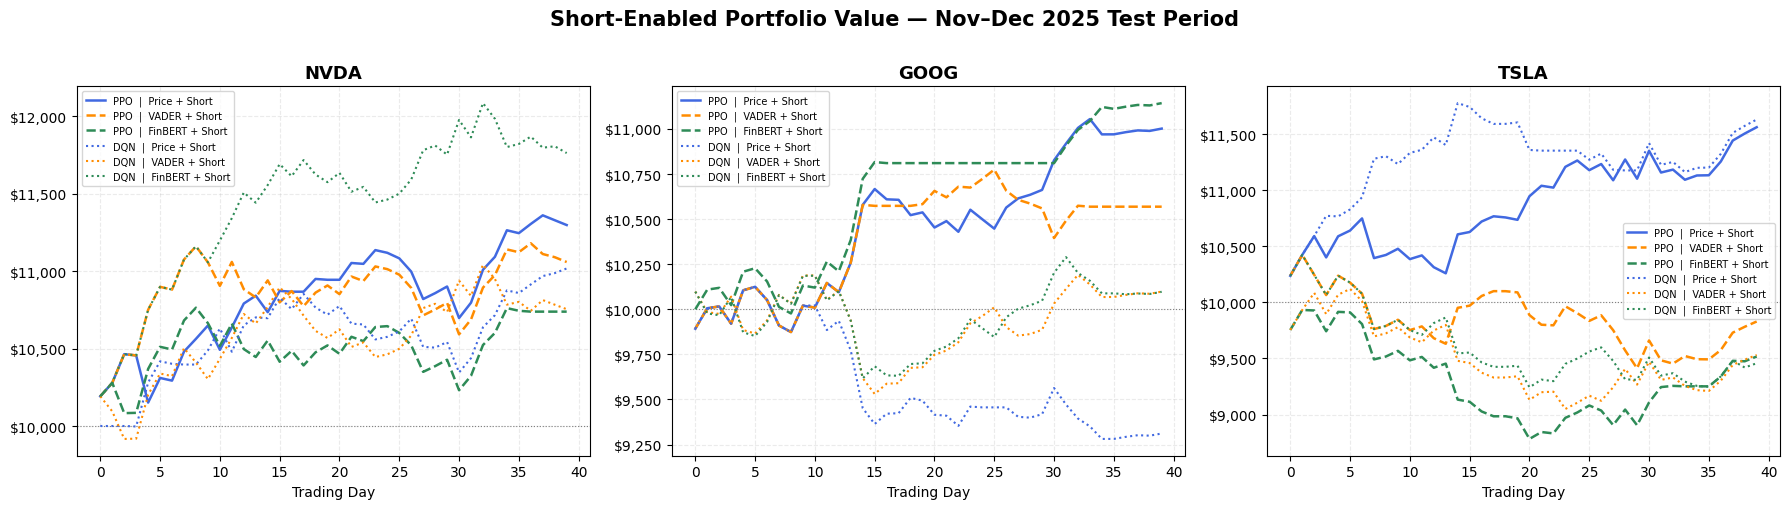

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False, facecolor='white')
fig.suptitle('Short-Enabled Portfolio Value — Nov–Dec 2025 Test Period', fontsize=15, fontweight='bold', y=1.01)

short_styles = {
    ('PPO', 'price_short'):             ('royalblue',  '-',  1.8, 'PPO  |  Price + Short'),
    ('PPO', 'sentiment_vader_short'):   ('darkorange', '--', 1.8, 'PPO  |  VADER + Short'),
    ('PPO', 'sentiment_finbert_short'): ('seagreen',   '--', 1.8, 'PPO  |  FinBERT + Short'),
    ('DQN', 'price_short'):             ('royalblue',  ':',  1.5, 'DQN  |  Price + Short'),
    ('DQN', 'sentiment_vader_short'):   ('darkorange', ':',  1.5, 'DQN  |  VADER + Short'),
    ('DQN', 'sentiment_finbert_short'): ('seagreen',   ':',  1.5, 'DQN  |  FinBERT + Short'),
}

for ax, ticker in zip(axes, TICKERS):
    ax.set_facecolor('white')
    ax.grid(alpha=0.25, linestyle='--', zorder=0)

    for (algo, state), (color, ls, lw, label) in short_styles.items():
        key = (ticker, algo, state)
        if key not in short_histories:
            continue
        h = short_histories[key]
        ax.plot(h['portfolio_value'].values, color=color, linestyle=ls, linewidth=lw, label=label, zorder=3)

    ax.axhline(INITIAL_CASH, color='gray', linewidth=0.8, linestyle=':', zorder=2)
    ax.set_title(ticker, fontsize=13, fontweight='bold')
    ax.set_xlabel('Trading Day')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'portfolio_value_short_3way.png', dpi=150, bbox_inches='tight')
plt.show()
